In [3]:
import pickle
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
drive.mount('/content/drive')
model_path = '/content/drive/MyDrive/air_pol_pipe_model.pkl'
data_path = '/content/drive/MyDrive/50k.csv'
# Load data
data = pd.read_csv(data_path)

# Recreate target
if 'High_Pollution' not in data.columns:
    data['High_Pollution'] = data['US_AQI'].apply(lambda x: 1 if x >= 150 else 0)

X = data.drop(columns=['High_Pollution'])
y = data['High_Pollution']

X = X.select_dtypes(include=['int64','float64'])

# Load full pipeline
with open(model_path, "rb") as f:
    pipeline = pickle.load(f)

# Predict directly
y_pred = pipeline.predict(X)

print("Predictions successful!")
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y, y_pred))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Predictions successful!
Accuracy: 0.99504

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     39152
           1       0.98      1.00      0.99     10848

    accuracy                           1.00     50000
   macro avg       0.99      1.00      0.99     50000
weighted avg       1.00      1.00      1.00     50000



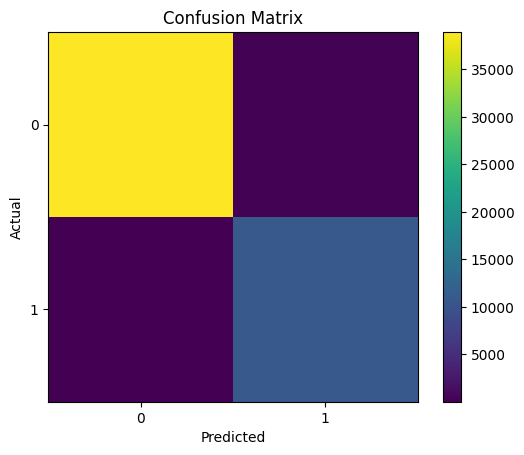

In [4]:
cm = confusion_matrix(y, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()
